In [133]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [134]:
df = pd.read_csv("../data/scores.csv")
df.head()

,id,date,artist,title,version,difficulty_rating,total_length,rank,accuracy,pp
0,7224346357,2026-08-06T16:09:21Z,DJ Fresh,Gold Dust,Kroytz's Extra,5.91602,88,B,0.867593,81.7551
1,7224337831,2026-08-06T16:07:47Z,DJ Fresh,Gold Dust,Kroytz's Extra,5.91602,88,B,0.900926,105.0100
2,7224329233,2026-08-06T16:06:12Z,DJ Fresh,Gold Dust,Kroytz's Extra,5.91602,88,B,0.910185,132.1870
3,7224320495,2026-08-06T16:04:37Z,LiSA,Rally Go Round -TV ver.-,Guy's Extra,5.54380,90,A,0.931562,96.1292
4,7224311702,2026-08-06T16:03:00Z,LiSA,Rally Go Round -TV ver.-,Guy's Extra,5.54380,90,A,0.961353,130.3090


In [135]:
df_pass = df[df["rank"] != "F"]

---

<Axes: xlabel='accuracy', ylabel='Count'>

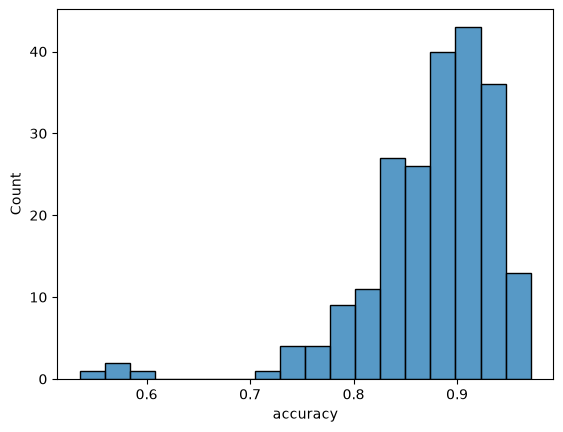

In [136]:
bins = np.histogram_bin_edges(df_pass["accuracy"], bins="fd")
sns.histplot(data=df_pass, x="accuracy", bins=bins)

In [137]:
df_pass["accuracy"].describe()

count    218.000000
mean       0.875657
std        0.065702
min        0.535384
25%        0.845979
50%        0.889210
75%        0.919777
max        0.971098
Name: accuracy, dtype: float64

/var/folders/tm/gzc0zpt11274nvk2hcv_rfd40000gn/T/ipykernel_8704/4137480290.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grades, x="rank", y="id", palette="Set2")


<Axes: xlabel='rank', ylabel='id'>

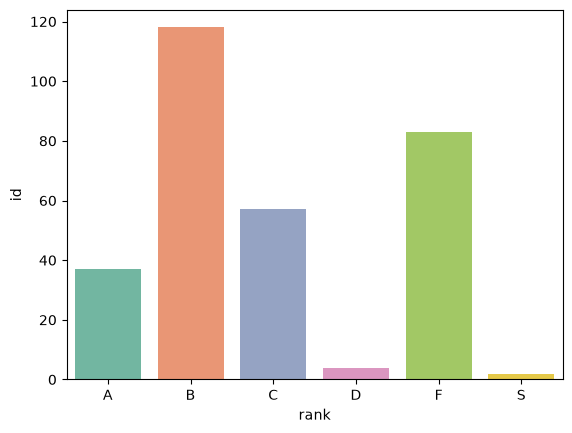

In [138]:
df_grades = df.groupby("rank")["id"].count().reset_index()
sns.barplot(data=df_grades, x="rank", y="id", palette="Set2")

In [139]:
len(df[df["rank"] != "F"]) / len(df)

0.7242524916943521

<Axes: xlabel='difficulty_rating', ylabel='Count'>

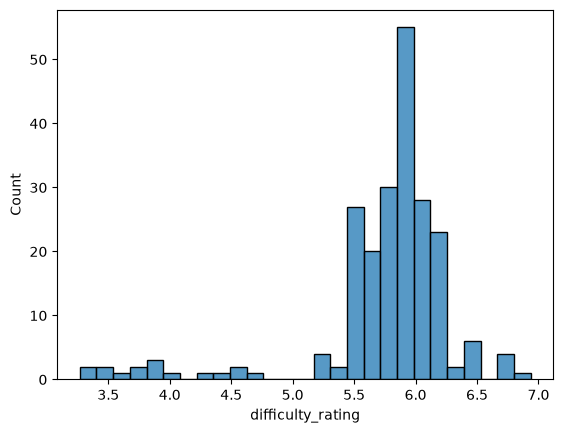

In [140]:
bins = np.histogram_bin_edges(df_pass["difficulty_rating"], bins="fd")
sns.histplot(data=df_pass, x="difficulty_rating", bins=bins)

In [141]:
df_pass["difficulty_rating"].describe()

count    218.000000
mean       5.744192
std        0.596190
min        3.267570
25%        5.603180
50%        5.867530
75%        6.012710
max        6.935960
Name: difficulty_rating, dtype: float64

/var/folders/tm/gzc0zpt11274nvk2hcv_rfd40000gn/T/ipykernel_8704/2050036179.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='difficulty_rating', ylabel='rank'>

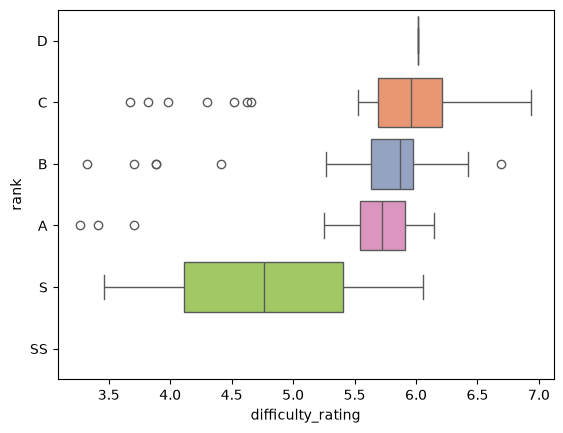

In [142]:
sns.boxplot(
    data=df_pass,
    x="difficulty_rating",
    y="rank",
    order=["D", "C", "B", "A", "S", "SS"],
    palette="Set2",
)

<Axes: xlabel='pp', ylabel='Count'>

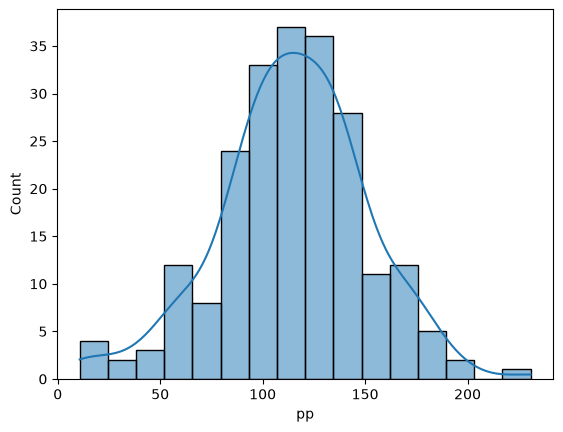

In [143]:
bins = np.histogram_bin_edges(df_pass["pp"], bins="fd")
sns.histplot(data=df_pass, x="pp", bins=bins, kde=True)

In [144]:
df_pass["full_title"] = df_pass["title"] + " [" + df_pass["version"] + "]"
maps_with_diff = set(df_pass["full_title"])
maps = set(df_pass["title"])

print(f"Maps with difficulty: {maps_with_diff}")
print(f"Total maps: {maps}")
print(f"Length of maps with difficulty: {len(maps_with_diff)}")
print(f"Length of total maps: {len(maps)}")

Maps with difficulty: {'Horrible Kids [Cataclysm]', "Rally Go Round -TV ver.- [Guy's Extra]", 'The Glory Days (TV Size) [Summer Sky]', "Start Again (Cut Ver.) [Fiery's Extreme]", 'PADORU / PADORU [Christmas Drift]', 'Wonder Stella [Stella]', "Today is Gonna be a Great Day (TV Size) [browiec's Something That Doesn't Exist]", "Start Again (Cut Ver.) [Koyomi's Extra]", "over the top [uri's extra]", 'Guinea Pig Bridge [Hard]', 'Say Goodbye (Sped Up & Cut Ver.) [Extra]', "Chikatto Chika Chika [Sotarks' 1+2 IQ]", 'Realize (TV Size) [Grasp of the Undying]', "Decided (TV Size) [Ram's Extreme]", 'JUSTadICE (TV Size) [Extreme]', "Gold Dust [Kroytz's Extra]", "Johnny Test Theme (TV Size) [Smoke's Turbocharged Backpack]", 'hate the way you love me (nightcore & cut ver.) [all your lies]', 'Answer (Game Ver.) [Nightfall]', '2 FACE [DECEITFUL]', 'ROCK-mode [Hard]', 'Bass Slut (Original Mix) [Intense Ecstasy]', "Responsibility Response [Slayed's Answer]", "Ai no Scenario [jieusieu's Solution]", "Kimi 

<Axes: xlabel='total_length', ylabel='Count'>

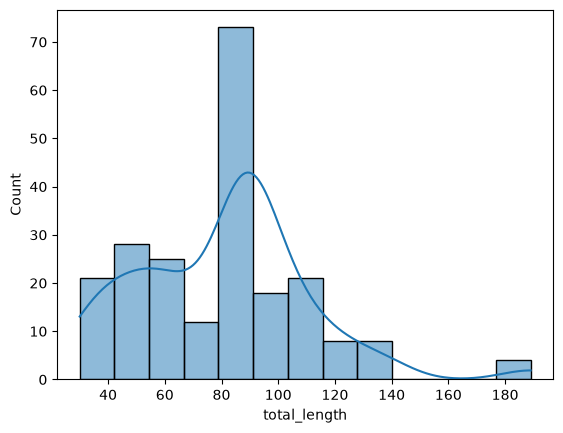

In [145]:
bins = np.histogram_bin_edges(df_pass["total_length"], bins="fd")
sns.histplot(data=df_pass, x="total_length", bins=bins, kde=True)

In [146]:
df_pass["total_length"].describe()

count    218.000000
mean      80.761468
std       30.482117
min       30.000000
25%       58.000000
50%       86.000000
75%       95.250000
max      189.000000
Name: total_length, dtype: float64

---

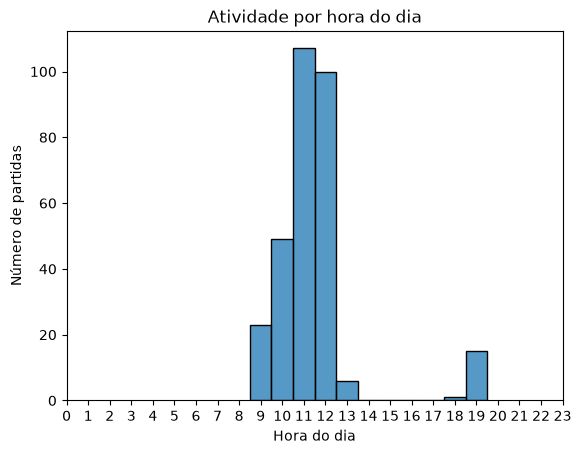

In [147]:
df["date"] = pd.to_datetime(df["date"], utc=True)
df["date"] = df["date"].dt.tz_convert("America/Belem")
df["day"] = df["date"].dt.date

hours = df["date"].dt.hour

sns.histplot(hours, bins=24, discrete=True)

plt.xlabel("Hora do dia")
plt.ylabel("Número de partidas")
plt.title("Atividade por hora do dia")
plt.xticks(range(24))
plt.show()

In [155]:
df_pass = df[df["rank"] != "F"]

df_day_hours = df_pass.groupby("day")["total_length"].sum().reset_index()

total_seconds = df_day_hours["total_length"]

df_day_hours["hours"] = total_seconds // 3600
df_day_hours["minutes"] = (total_seconds % 3600) // 60
df_day_hours["seconds"] = total_seconds % 60
df_day_hours["formatted_time"] = df_day_hours.apply(
    lambda row: (
        f"{int(row['hours']):02d}:{int(row['minutes']):02d}:{int(row['seconds']):02d}"
    ),
    axis=1,
)
df_day_hours

,day,total_length,hours,minutes,seconds,formatted_time
0,2026-08-05,122,0,2,2,00:02:02
1,2026-08-06,3939,1,5,39,01:05:39
2,2026-08-07,4247,1,10,47,01:10:47
3,2026-08-08,4366,1,12,46,01:12:46
4,2026-08-09,3717,1,1,57,01:01:57
5,2026-08-10,1215,0,20,15,00:20:15


---

In [149]:
df_pp = (
    df_pass.groupby(["title", "version"])["pp"]
    .mean()
    .reset_index()
    .sort_values(by="pp", ascending=False)
)
df_pp["full_title"] = df_pp["title"] + " (" + df_pp["version"] + ")"
df_pp

,title,version,pp,full_title
28,Forget About Me (Cut Ver.),Save Me,230.769000,Forget About Me (Cut Ver.) (Save Me)
48,Johnny Test Theme (TV Size),Air-Breathing Shark,186.853000,Johnny Test Theme (TV Size) (Air-Breathing Shark)
64,Mizuoto to Curtain,Lucid,167.941000,Mizuoto to Curtain (Lucid)
84,Start Again (Cut Ver.),Fiery's Extreme,167.082000,Start Again (Cut Ver.) (Fiery's Extreme)
65,Monochrome Butterfly,Uniform,164.135000,Monochrome Butterfly (Uniform)
...,...,...,...,...
18,Cherry Bomb,Hard,40.568600,Cherry Bomb (Hard)
41,Harumachi Clover (Swing Arrangement) [Dictate ...,Shunao's Hard,39.338600,Harumachi Clover (Swing Arrangement) [Dictate ...
37,Guinea Pig Bridge,Light Insane,33.763800,Guinea Pig Bridge (Light Insane)
35,Guinea Pig Bridge,Hard,28.004900,Guinea Pig Bridge (Hard)


<Axes: xlabel='pp', ylabel='full_title'>

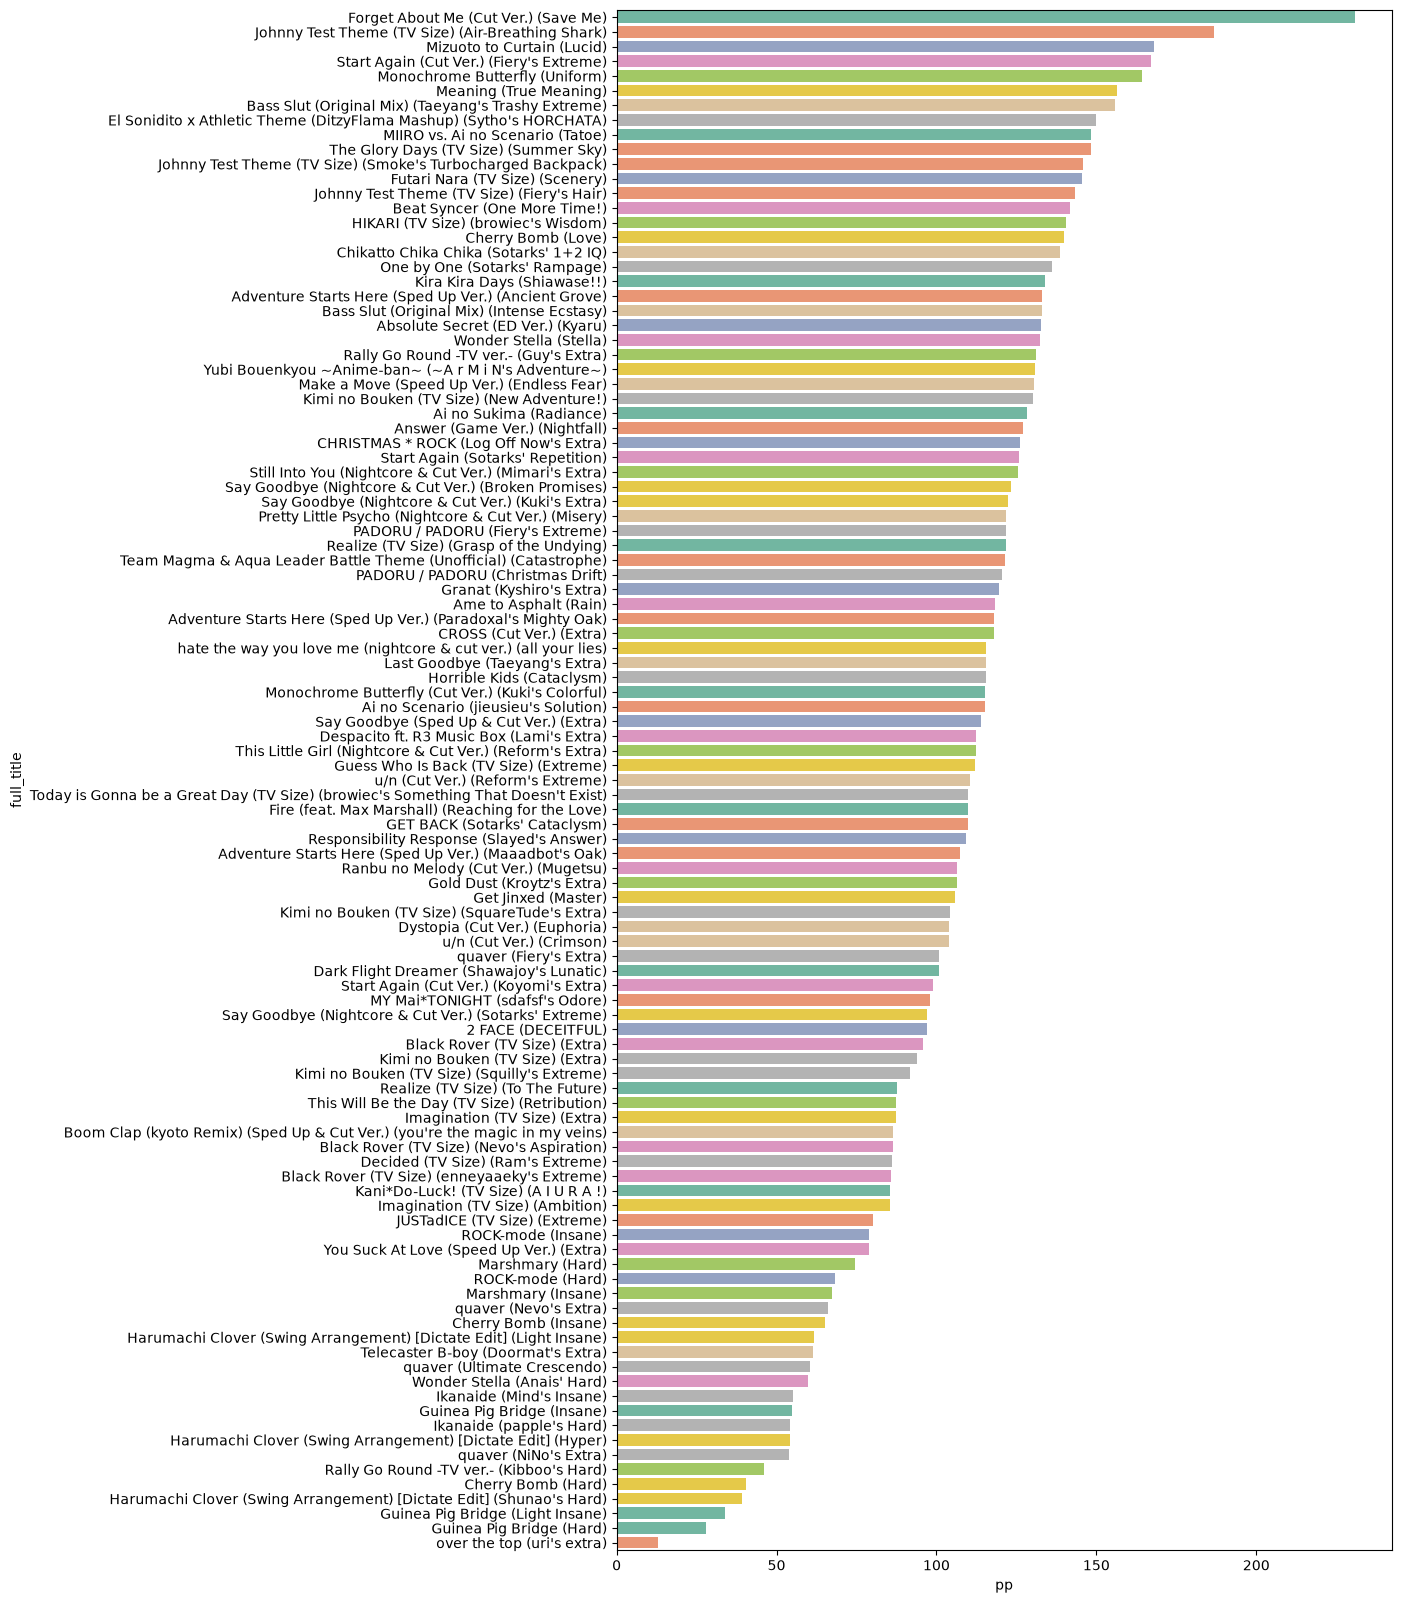

In [150]:
plt.figure(figsize=(10, 20))
sns.barplot(
    data=df_pp,
    x="pp",
    y="full_title",
    hue="title",
    orient="h",
    legend=False,
    palette="Set2",
)